# Plotting scale cuts and baryon vs no baryon difference

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [32]:
def get_theta(theta_min, theta_max, num_theta):
    ARCMIN_TO_RAD = 2.90888208665721580e-4
    RAD_TO_ARCMIN = 1/ARCMIN_TO_RAD

    THETA_MIN_RAD = theta_min * ARCMIN_TO_RAD
    THETA_MAX_RAD = theta_max * ARCMIN_TO_RAD
    DLOG_THETA = (np.log(THETA_MAX_RAD) - np.log(THETA_MIN_RAD))/num_theta
    theta = np.zeros(num_theta)
    for i in range(num_theta):
        THETA_MIN_BIN = np.exp(np.log(THETA_MIN_RAD) + i * DLOG_THETA)
        THETA_MAX_BIN = np.exp(np.log(THETA_MIN_RAD) + (i + 1) * DLOG_THETA)
        theta[i] = (2/3) * (THETA_MAX_BIN**3 - THETA_MIN_BIN**3) / (THETA_MAX_BIN**2 - THETA_MIN_BIN**2)

    theta *= RAD_TO_ARCMIN
    return theta

def find_minimum_angles_from_mask(mask, thetas):
    NUM_SOURCE_BINS = 5
    NUM_SHEAR_2PCFS = 2 * 36
    
    min_angles_shear = np.zeros(NUM_SHEAR_2PCFS)
    for i in range(NUM_SHEAR_2PCFS):
        for j in range(i*len(thetas), (i+1)*len(thetas)):
            if mask[j] == 1:
                min_angles_shear[i] = (thetas[j%len(thetas)] + thetas[(j-1)%len(thetas)])/2
                break
        if min_angles_shear[i] == 0: min_angles_shear[i] = thetas[-1] + 10
    return min_angles_shear

SHEAR_LEN = 1080
cov = np.zeros((SHEAR_LEN, SHEAR_LEN))
with open("../cov_sim_cosmolike_format.dat", "r") as f:
    for line in f.read().splitlines():
        if line.startswith("#"): continue
        words = line.split()
        i = int(words[0])
        j = int(words[1])
        if i >= SHEAR_LEN or j >= SHEAR_LEN: continue
        cov[i,j] = float(words[8]) + float(words[9])
        cov[j,i] = cov[i,j]

In [22]:
thetas = get_theta(2.5, 250, 15)

In [44]:
_, dv_baseline  = np.loadtxt("BASELINE.modelvector", unpack=True)
_, dv_baryons   = np.loadtxt("BARYONS.modelvector", unpack=True)
_, dv_nobaryons = np.loadtxt("NOBARYONS.modelvector", unpack=True)
_, mask         = np.loadtxt("dchi2_05.mask", unpack=True)
min_angles = find_minimum_angles_from_mask(mask, thetas)

## Plot both data vectors

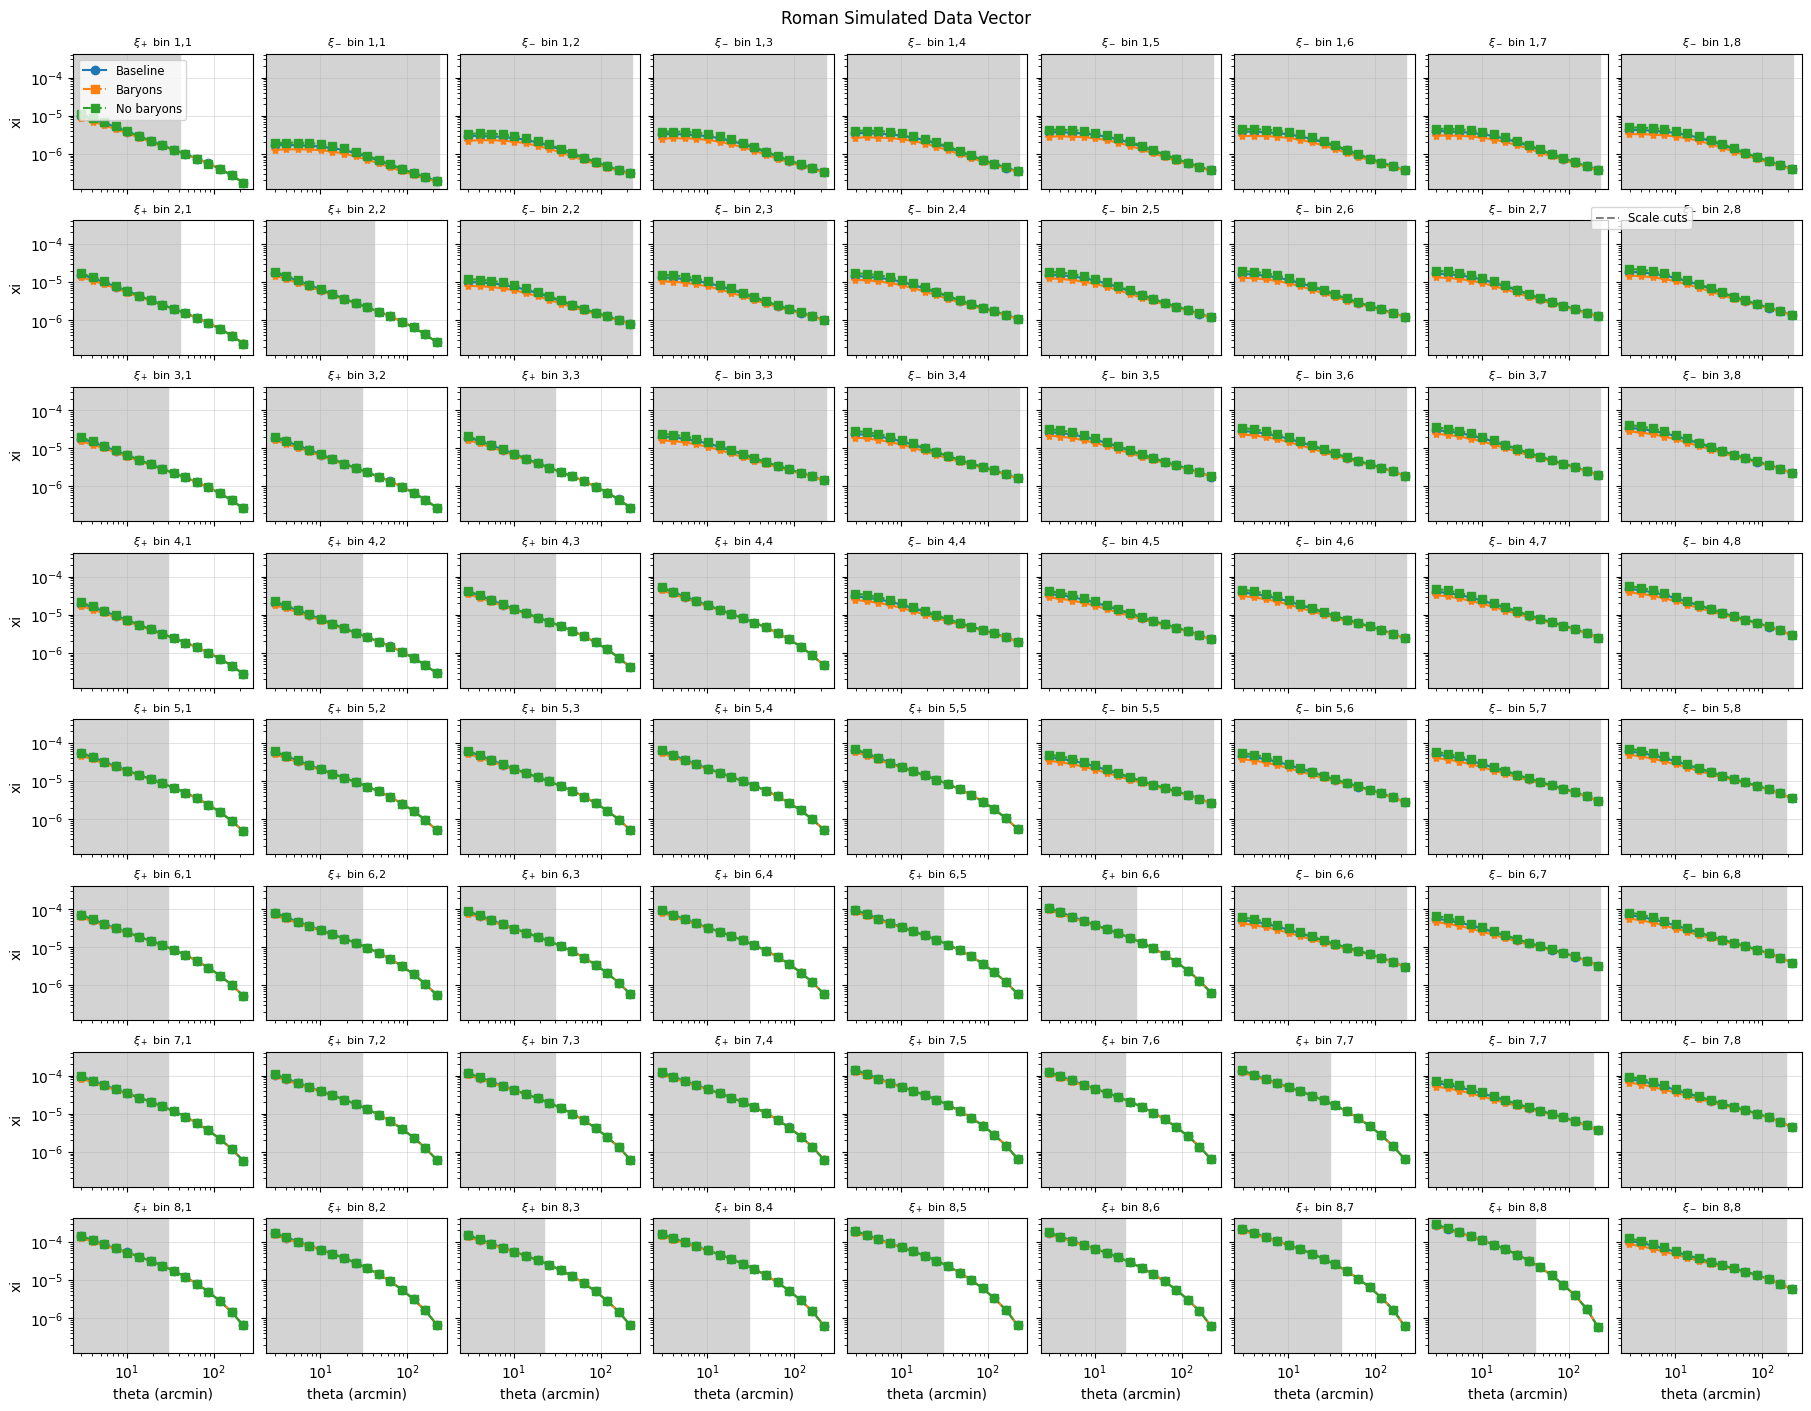

In [47]:
num_bins = 8
num_cols = num_bins+1
block_size = 15
tri_count = num_bins * (num_bins + 1) // 2

xi_plus_baseline   = dv_baseline[:tri_count*block_size]
xi_minus_baseline  = dv_baseline[tri_count*block_size:2*tri_count*block_size]
xi_plus_baryons    = dv_baryons[:tri_count*block_size]
xi_minus_baryons   = dv_baryons[tri_count*block_size:2*tri_count*block_size]
xi_plus_nobaryons  = dv_nobaryons[:tri_count*block_size]
xi_minus_nobaryons = dv_nobaryons[tri_count*block_size:2*tri_count*block_size]

fig, axes = plt.subplots(num_bins, num_cols, figsize=(18, 14), sharex=True, sharey=True, constrained_layout=True)
plus_idx = 0
minus_idx = 0

for i in range(num_bins):
    for col in range(num_cols):
        ax = axes[i, col]

        if col <= i:
            j = col
            start = plus_idx * block_size
            end = start + block_size
            ax.loglog(thetas, xi_plus_baseline[start:end], color='C0', marker='o', linestyle='-')
            ax.loglog(thetas, xi_plus_baryons[start:end], color='C1', marker='*', linestyle='-')
            ax.loglog(thetas, xi_plus_nobaryons[start:end], color='C2', marker='s', linestyle='--')
            line_idx = plus_idx
            plus_idx += 1
            label = r'$\xi_+$'
        else:
            j = col - 1
            start = minus_idx * block_size
            end = start + block_size
            ax.loglog(thetas, xi_minus_baseline[start:end], color='C0', marker='o', linestyle='-')
            ax.loglog(thetas, xi_minus_baryons[start:end], color='C1', marker='*', linestyle='-')
            ax.loglog(thetas, xi_minus_nobaryons[start:end], color='C2', marker='s', linestyle='--')
            line_idx = tri_count + minus_idx
            minus_idx += 1
            label = r'$\xi_-$'

        # ax.axvline(min_angles[line_idx], color='gray', linestyle='--', linewidth=1)
        ax.axvspan(0, min_angles[line_idx], color='lightgray')
        
        if i == num_bins - 1:
            ax.set_xlabel('theta (arcmin)')
        if col == 0:
            ax.set_ylabel('xi')

        ax.set_title(f'{label} bin {i+1},{j+1}', fontsize=8)
        ax.grid(True, linewidth=0.5, alpha=0.5)

legend_lines = [Line2D([0], [0], color='C0', marker='o', linestyle='-'),
                Line2D([0], [0], color='C1', marker='s', linestyle='--'),
                Line2D([0], [0], color='C2', marker='s', linestyle='--')]
legend_labels = ['Baseline', 'Baryons', 'No baryons']
axes[0, 0].legend(legend_lines, legend_labels, fontsize='small', loc='upper left')

scale_cut_lines = [Line2D([0], [0], color='gray', linestyle='--'),
                   Line2D([0], [0], color='red', linestyle='--'),
                   Line2D([0], [0], color='blue', linestyle='--'),
                   ]
scale_cut_labels = ['Scale cuts']
fig.legend(scale_cut_lines, scale_cut_labels, fontsize='small', loc='upper right', bbox_to_anchor=(0.94, 0.86))

fig.suptitle('Roman Simulated Data Vector')
plt.show()

## Plot absolute difference

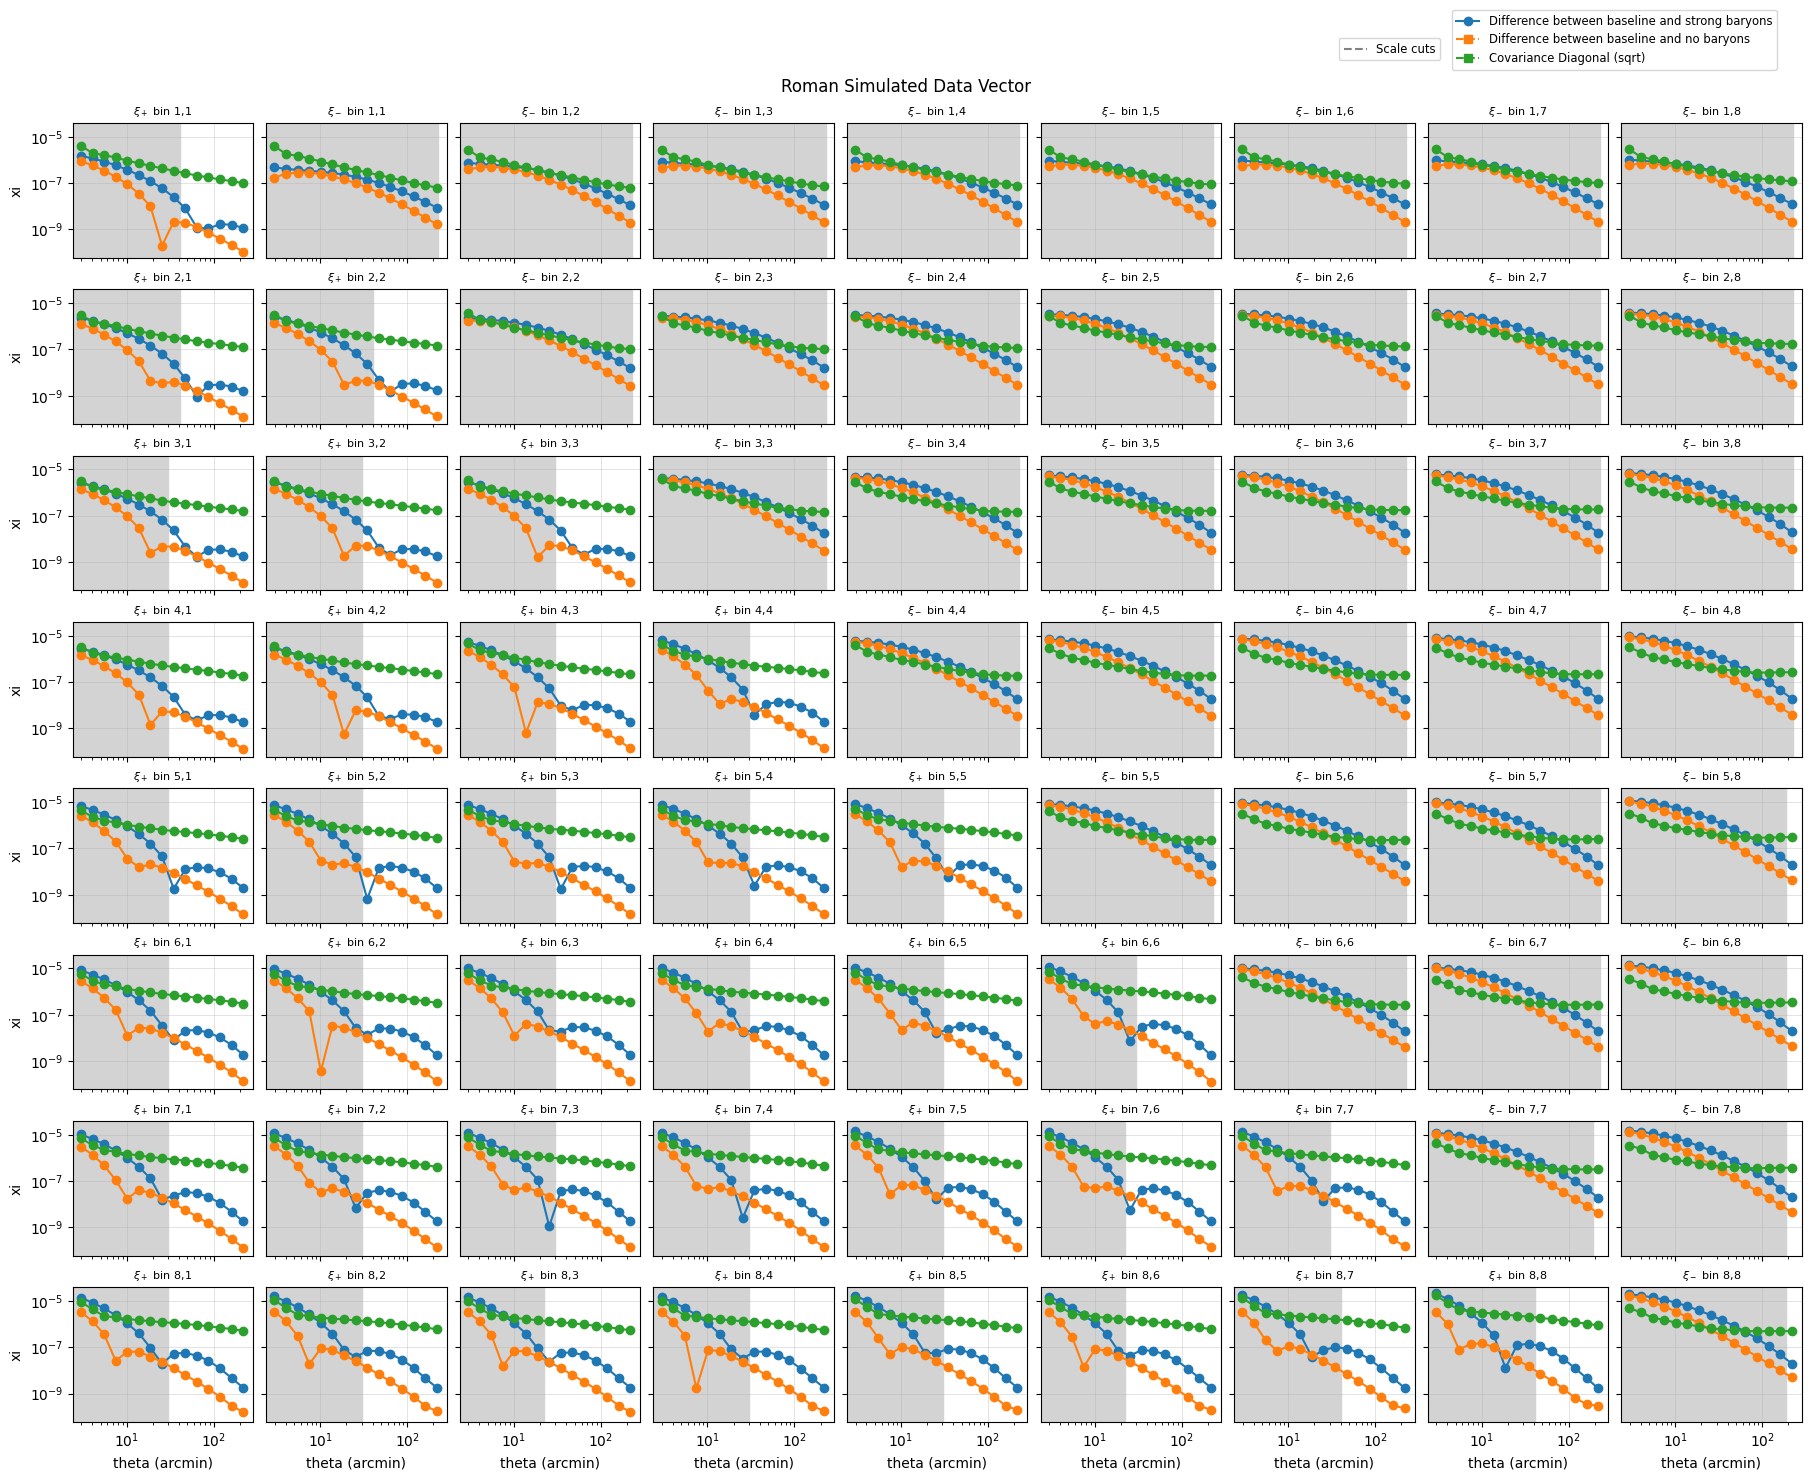

In [48]:
num_bins = 8
num_cols = num_bins+1
block_size = 15
tri_count = num_bins * (num_bins + 1) // 2

stdevs = np.sqrt(np.diag(cov))
stdevs_xi_plus     = stdevs[:tri_count*block_size]
stdevs_xi_minus    = stdevs[tri_count*block_size:2*tri_count*block_size]
xi_plus_baseline   = dv_baseline[:tri_count*block_size]
xi_minus_baseline  = dv_baseline[tri_count*block_size:2*tri_count*block_size]
xi_plus_baryons    = dv_baryons[:tri_count*block_size]
xi_minus_baryons   = dv_baryons[tri_count*block_size:2*tri_count*block_size]
xi_plus_nobaryons  = dv_nobaryons[:tri_count*block_size]
xi_minus_nobaryons = dv_nobaryons[tri_count*block_size:2*tri_count*block_size]

fig, axes = plt.subplots(num_bins, num_cols, figsize=(18, 14), sharex=True, sharey=True, constrained_layout=True)
plus_idx = 0
minus_idx = 0

for i in range(num_bins):
    for col in range(num_cols):
        ax = axes[i, col]

        if col <= i:
            j = col
            start = plus_idx * block_size
            end = start + block_size
            diff_baryons = xi_plus_baseline[start:end] - xi_plus_baryons[start:end]
            diff_nobaryons = xi_plus_baseline[start:end] - xi_plus_nobaryons[start:end]
            
            ax.loglog(thetas, np.abs(diff_baryons), color='C0', marker='o', linestyle='-')
            ax.loglog(thetas, np.abs(diff_nobaryons), color='C1', marker='o', linestyle='-')
            ax.loglog(thetas, stdevs_xi_plus[start:end], color='C2', marker='o', linestyle='-')
            line_idx = plus_idx
            plus_idx += 1
            label = r'$\xi_+$'
        else:
            j = col - 1
            start = minus_idx * block_size
            end = start + block_size

            diff_baryons = xi_minus_baseline[start:end] - xi_minus_baryons[start:end]
            diff_nobaryons = xi_minus_baseline[start:end] - xi_minus_nobaryons[start:end]
                        
            ax.loglog(thetas, np.abs(diff_baryons), color='C0', marker='o', linestyle='-')
            ax.loglog(thetas, np.abs(diff_nobaryons), color='C1', marker='o', linestyle='-')
            ax.loglog(thetas, stdevs_xi_minus[start:end], color='C2', marker='o', linestyle='-')
            line_idx = tri_count + minus_idx
            minus_idx += 1
            label = r'$\xi_-$'

        ax.axvspan(0, min_angles[line_idx], color='lightgray')
        
        if i == num_bins - 1:
            ax.set_xlabel('theta (arcmin)')
        if col == 0:
            ax.set_ylabel('xi')

        ax.set_title(f'{label} bin {i+1},{j+1}', fontsize=8)
        ax.grid(True, linewidth=0.5, alpha=0.5)

legend_lines = [Line2D([0], [0], color='C0', marker='o', linestyle='-'),
                Line2D([0], [0], color='C1', marker='s', linestyle='--'),
                Line2D([0], [0], color='C2', marker='s', linestyle='--')]
legend_labels = ['Difference between baseline and strong baryons', 'Difference between baseline and no baryons', 'Covariance Diagonal (sqrt)']
fig.legend(legend_lines, legend_labels, fontsize='small', loc='upper left', bbox_to_anchor=(0.8, 1.05))

scale_cut_lines = [Line2D([0], [0], color='gray', linestyle='--'),
                   Line2D([0], [0], color='red', linestyle='--'),
                   Line2D([0], [0], color='blue', linestyle='--'),
                   ]
scale_cut_labels = ['Scale cuts']
fig.legend(scale_cut_lines, scale_cut_labels, fontsize='small', loc='upper right', bbox_to_anchor=(0.8, 1.03))

fig.suptitle('Roman Simulated Data Vector')
plt.show()